# **ASSIGNMENT GROUP 12 NOTEBOOK**


# Importing and Setup

In [32]:
from __future__ import annotations
from pathlib import Path
import io, zipfile, importlib.util, re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import requests
except Exception:
    requests = None

if importlib.util.find_spec('statsmodels') is None:
    raise ModuleNotFoundError('Run: %pip install statsmodels')
import statsmodels.api as sm

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')


## Data Loading

**Screen:** Through CapitalIQ, we screened for 3 factors:
- **P/BV** *(LTM as of 12/31/2014)*
- **% Price change** *(12/31/2013–12/31/2014)*
- **Return on Equity** *(FY 2014)*

732 stocks were each given a score (lower = better) based on their relative ranking across the 3 factors. The 7 stocks with the lowest aggregate score were selected.

**Data:** Monthly dividend-adjusted share prices for TTWO, GHC, HQH, GBX, RDN, BBAR, SANM and **SPY** (S&P 500 total return proxy) from `Charting Excel Export - Test.xls`.

Monthly simple returns are computed as $r_t = P_t / P_{t-1} - 1$.

In [33]:
DATA_PATH  = '/content/sample_data/Charting Excel Export - Test.xls'
START_DATE = pd.Timestamp('1998-01-01')
END_DATE   = pd.Timestamp('2024-12-01')
SPLIT_DATE = pd.Timestamp('2015-01-01')  # in-sample: < SPLIT_DATE; out-of-sample: >= SPLIT_DATE

def _load_charting_xls(path: str) -> pd.DataFrame:
    """Load Capital IQ Charting Excel Export, return monthly beginning-of-month price DataFrame."""
    raw = pd.read_excel(path, sheet_name='Pane 1', header=None)
    data = raw[raw.notna().any(axis=1)].copy()
    data.columns = data.iloc[0]
    data = data.iloc[1:].copy()
    data = data.rename(columns={data.columns[0]: 'date'})
    data['date'] = pd.to_datetime(data['date'])
    data = data.set_index('date').apply(pd.to_numeric, errors='coerce')
    # Capital IQ sometimes labels end-of-month prices on the 1st of the next month.
    # Shift those dates back one day so they fall in the correct month.
    data.index = data.index - pd.to_timedelta((data.index.day == 1).astype(int), unit='D')
    data = data.resample('ME').last()
    data.index = data.index.to_period('M').to_timestamp()
    return data

def _extract_ticker(col: str) -> str:
    m = re.search(r'\((?:[A-Za-z]+:)?([A-Z]+)\)', col)
    return m.group(1) if m else col

all_prices = _load_charting_xls(DATA_PATH)
all_prices.columns = [_extract_ticker(c) for c in all_prices.columns]
all_ret = all_prices.pct_change().dropna(how='all')

stock_tickers = [c for c in all_ret.columns if c != 'SPY']
df_ret = all_ret.join(all_ret[['SPY']], how='inner', rsuffix='_dup').dropna(how='all')
df_ret = all_ret.dropna(how='all').loc[START_DATE:END_DATE]
df_ret.index.name = 'date'

print(f'Rows (months): {df_ret.shape[0]}, Assets: {df_ret.shape[1]}')
print(f'Date range: {df_ret.index.min().date()} to {df_ret.index.max().date()}')
df_ret.head()

Rows (months): 324, Assets: 8
Date range: 1998-01-01 to 2024-12-01


,GHC,TTWO,HQH,GBX,RDN,BBAR,SANM,SPY
date,,,,,,,,
1998-01-01,0.008887,0.136360,0.040983,-0.058117,0.074816,0.008065,0.132911,0.041986
1998-02-01,0.012004,0.140001,0.074803,-0.007722,0.078950,0.154286,0.175047,0.069715
1998-03-01,0.097086,0.122804,0.007327,0.073930,-0.029091,-0.009901,-0.113311,0.054745
1998-04-01,-0.009306,0.046875,-0.010909,0.061497,-0.032772,-0.030000,0.286863,0.012791
1998-05-01,0.031153,-0.074624,-0.014706,-0.013699,-0.062488,-0.210310,-0.134723,-0.020769


## Fama-French Factor Data

Monthly FF5 factors (Mkt-RF, SMB, HML, RMW, CMA) and the risk-free rate (RF) are downloaded from the [Ken French Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html). Values are reported in percent and converted to decimal. The dataset is merged with stock returns on date and split into in-sample (1998–2014) and out-of-sample (2015–2024) windows.

In [34]:
FF_ZIP_URL  = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip'
LOCAL_FF_ZIP = Path('F-F_Research_Data_5_Factors_2x3_CSV.zip')  # local fallback if download fails

def read_ff_zip(zip_bytes: bytes) -> pd.DataFrame:
    z = zipfile.ZipFile(io.BytesIO(zip_bytes))
    with z.open(z.namelist()[0]) as f:
        df_factors = pd.read_csv(f, skiprows=3, index_col=0)
    df_factors = df_factors.loc[:'202412']  # monthly data only
    df_factors.index = pd.to_datetime(df_factors.index, format='%Y%m')
    df_factors = df_factors.apply(pd.to_numeric, errors='coerce') / 100.0
    return df_factors.rename_axis('date').reset_index()

try:
    if requests is None: raise ModuleNotFoundError('requests unavailable')
    resp = requests.get(FF_ZIP_URL, timeout=30)
    resp.raise_for_status()
    df_factors = read_ff_zip(resp.content)
    print('FF5 data: downloaded from Ken French website.')
except Exception as e:
    if LOCAL_FF_ZIP.exists():
        df_factors = read_ff_zip(LOCAL_FF_ZIP.read_bytes())
        print(f'FF5 data: loaded from local file ({type(e).__name__}).')
    else:
        raise RuntimeError('Could not load FF5 data. Download the ZIP from Ken French and place it in the working directory.') from e

# Merge stock returns with FF factors on date
df = df_ret.reset_index().merge(df_factors, how='inner', on='date').set_index('date').sort_index()

# Convenience references
rf             = df['RF']
market_excess  = df['Mkt-RF']

# Train / test split
train = df.loc[df.index < SPLIT_DATE].copy()
test  = df.loc[df.index >= SPLIT_DATE].copy()

print(f'Full dataset:      {df.shape[0]} months ({df.index.min().date()} to {df.index.max().date()})')
print(f'In-sample (train): {len(train)} months ({train.index.min().date()} to {train.index.max().date()})')
print(f'Out-of-sample:     {len(test)} months ({test.index.min().date()} to {test.index.max().date()})')


FF5 data: downloaded from Ken French website.
Full dataset:      324 months (1998-01-01 to 2024-12-01)
In-sample (train): 204 months (1998-01-01 to 2014-12-01)
Out-of-sample:     120 months (2015-01-01 to 2024-12-01)


##Stock Selection

The seven stocks selected are: **TTWO, GHC, HQH, GBX, RDN, BBAR, SANM**. Each stock was chosen based on a composite score across P/BV, 12-month price momentum, and ROE using CapitalIQ screening data as at December 2014 (end of in-sample period).

In [35]:
my_stock_selection = [c for c in df_ret.columns if c != 'SPY']

missing = set(my_stock_selection) - set(df.columns)
if missing:
    raise ValueError(f'Tickers not in merged dataset: {missing}')

print('Selected stocks:', my_stock_selection)

# Stock return series (full sample, for reference)
stocks = df[my_stock_selection].copy()

Selected stocks: ['GHC', 'TTWO', 'HQH', 'GBX', 'RDN', 'BBAR', 'SANM']


##Summary Statistics and Correlation Matrix (In-Sample)

All statistics are computed using the **in-sample period (January 1998 – December 2014)** only

In [36]:
#Monthly return summary statistics (in-sample)
stocks_train_ret = train[my_stock_selection]

summary_stats = pd.DataFrame({
    'Min':    stocks_train_ret.min(),
    'Max':    stocks_train_ret.max(),
    'Mean':   stocks_train_ret.mean(),
    'Median': stocks_train_ret.median(),
    'Std Dev': stocks_train_ret.std(ddof=1),
})
print('=== Section 4a: In-Sample Monthly Return Summary Statistics ===')
summary_stats

=== Section 4a: In-Sample Monthly Return Summary Statistics ===


,Min,Max,Mean,Median,Std Dev
GHC,-0.337562,0.289023,0.006580,0.002664,0.068138
TTWO,-0.574097,0.954739,0.024330,0.016843,0.174990
HQH,-0.262069,0.491586,0.014325,0.013780,0.083784
GBX,-0.615768,1.170918,0.020365,0.002553,0.173695
RDN,-0.746946,1.754571,0.022120,0.005434,0.233591
BBAR,-0.547406,0.459854,0.024406,0.015082,0.155600
SANM,-0.585366,1.386418,0.017358,0.014460,0.210569


=== Section 4b: In-Sample Correlation Matrix ===


,GHC,TTWO,HQH,GBX,RDN,BBAR,SANM
GHC,1.000000,0.227100,0.161700,0.438300,0.274400,0.220000,0.239200
TTWO,0.227100,1.000000,0.280600,0.152500,0.112000,0.188500,0.293200
HQH,0.161700,0.280600,1.000000,0.138700,0.089000,0.239400,0.403500
GBX,0.438300,0.152500,0.138700,1.000000,0.252200,0.244400,0.384700
RDN,0.274400,0.112000,0.089000,0.252200,1.000000,0.239600,0.391800
BBAR,0.220000,0.188500,0.239400,0.244400,0.239600,1.000000,0.326900
SANM,0.239200,0.293200,0.403500,0.384700,0.391800,0.326900,1.000000


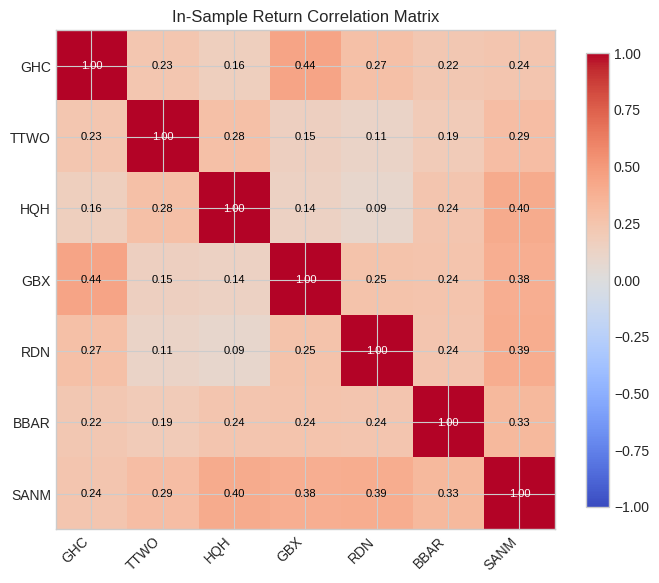

In [37]:
#Correlation matrix (in-sample)
corr = stocks_train_ret.corr()
print('=== Section 4b: In-Sample Correlation Matrix ===')
display(corr.round(4))

fig, ax = plt.subplots(figsize=(7, 6))
img = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(my_stock_selection)))
ax.set_yticks(range(len(my_stock_selection)))
ax.set_xticklabels(my_stock_selection, rotation=45, ha='right')
ax.set_yticklabels(my_stock_selection)
ax.set_title('In-Sample Return Correlation Matrix', fontsize=12)
for i in range(len(my_stock_selection)):
    for j in range(len(my_stock_selection)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.values[i,j]) > 0.6 else 'black')
fig.colorbar(img, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

##Portfolio Construction: Markowitz and Tikhonov Optimal Portfolios

Portfolio weights are estimated using **in-sample data only (1998–2014)** to avoid look-ahead bias. The risk-free rate is the 1-month Treasury bill rate from the Ken French Data Library.

In [38]:
def tangency_weights(Sigma: np.ndarray, mu_excess: np.ndarray) -> np.ndarray:
    """Compute tangency (maximum Sharpe ratio) portfolio weights.
    w = (Σ⁻¹ μᵉ) / (1ᵀ Σ⁻¹ μᵉ)
    """
    mu_excess = np.asarray(mu_excess, dtype=float).reshape(-1)
    z = np.linalg.pinv(Sigma) @ mu_excess
    denom = np.ones_like(mu_excess) @ z
    if np.isclose(denom, 0.0):
        raise ValueError('Normalisation failed: 1ᵀ Σ⁺ μᵉ ≈ 0.')
    return z / denom

In [39]:
#In-sample inputs
stocks_train   = train[my_stock_selection].copy()
stocks_excess_train = stocks_train.subtract(train['RF'], axis=0)
mu_e_train     = stocks_excess_train.mean()

R_train        = stocks_train.subtract(stocks_train.mean())
T_train        = len(stocks_train)
Sigma_train    = (R_train.T @ R_train) / (T_train - 1)  # unbiased sample covariance

#Markowitz tangency portfolio
w_mkv_train = pd.Series(
    tangency_weights(Sigma_train.values, mu_e_train.values),
    index=my_stock_selection, name='Markowitz'
)

#Tikhonov regularised portfolio (λ = 0.6 as specified)
LAMBDA = 0.6
Sigma_tikh = Sigma_train.values + LAMBDA * np.eye(Sigma_train.shape[0])
w_tikh_train = pd.Series(
    tangency_weights(Sigma_tikh, mu_e_train.values),
    index=my_stock_selection, name='Tikhonov (λ=0.6)'
)

w_eq_train = pd.Series(
    np.repeat(1 / len(my_stock_selection), len(my_stock_selection)),
    index=my_stock_selection, name='Equal-weighted'
)

weights_table = pd.concat([w_eq_train, w_mkv_train, w_tikh_train], axis=1)
print(f'Tikhonov λ = {LAMBDA}')
weights_table

Tikhonov λ = 0.6


,Equal-weighted,Markowitz,Tikhonov (λ=0.6)
GHC,0.142857,-0.128109,0.040263
TTWO,0.142857,0.191381,0.198018
HQH,0.142857,0.565814,0.113537
GBX,0.142857,0.175936,0.159385
RDN,0.142857,0.101988,0.167457
BBAR,0.142857,0.243203,0.199370
SANM,0.142857,-0.150213,0.121971


In [40]:
#Expected return and Sharpe ratio for each portfolio
def portfolio_stats(w, mu_e, Sigma, rf_mean, label):
    """Expected excess return, volatility, and Sharpe ratio for a portfolio."""
    exp_excess  = float(w @ mu_e)
    exp_ret     = exp_excess + rf_mean
    vol         = float(np.sqrt(w @ Sigma @ w))
    sharpe      = exp_excess / vol
    return pd.Series({
        'Expected return (monthly)':        exp_ret,
        'Expected excess return (monthly)': exp_excess,
        'Volatility (monthly)':             vol,
        'Sharpe ratio (monthly)':           sharpe,
        'Sharpe ratio (annualised)':        sharpe * np.sqrt(12),
    }, name=label)

rf_mean_train = train['RF'].mean()
Sigma_np = Sigma_train.values

portfolio_stats_table = pd.concat([
    portfolio_stats(w_eq_train.values,   mu_e_train.values, Sigma_np, rf_mean_train, 'Equal-weighted'),
    portfolio_stats(w_mkv_train.values,  mu_e_train.values, Sigma_np, rf_mean_train, 'Markowitz'),
    portfolio_stats(w_tikh_train.values, mu_e_train.values, Sigma_np, rf_mean_train, 'Tikhonov (λ=0.6)'),
], axis=1).T
print('Portfolio Expected Return and Sharpe Ratio (In-Sample)')
portfolio_stats_table

Portfolio Expected Return and Sharpe Ratio (In-Sample)


,Expected return (monthly),Expected excess return (monthly),Volatility (monthly),Sharpe ratio (monthly),Sharpe ratio (annualised)
Equal-weighted,0.018498,0.016697,0.096806,0.172477,0.597476
Markowitz,0.021086,0.019285,0.086539,0.222845,0.771959
Tikhonov (λ=0.6),0.020642,0.018841,0.105139,0.179202,0.620774


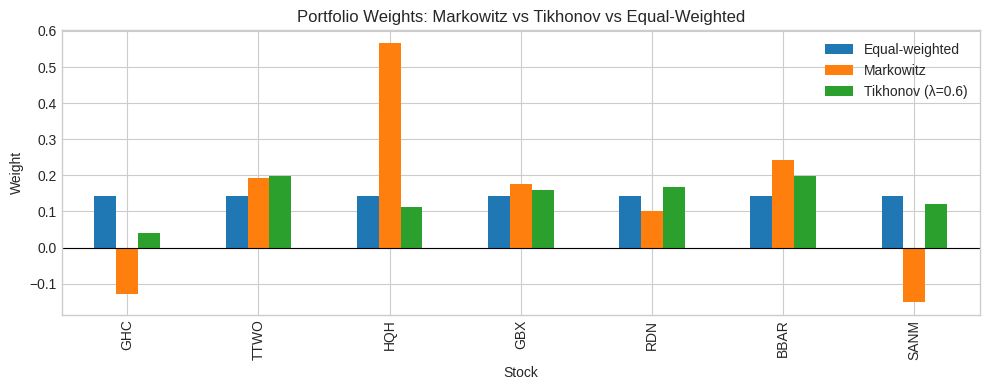

In [41]:
#Weight comparison
ax = weights_table.plot(kind='bar', figsize=(10, 4))
ax.set_title('Portfolio Weights: Markowitz vs Tikhonov vs Equal-Weighted', fontsize=12)
ax.set_xlabel('Stock')
ax.set_ylabel('Weight')
ax.axhline(0.0, color='black', linewidth=0.8)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## In-Sample Performance Analysis

Portfolio returns are computed as the weighted average of individual stock returns each month (constant weights, monthly rebalancing). The in-sample period is **January 1998 – December 2014** (204 months).

### Portfolio Return Construction

In [42]:
# Portfolio return series (in-sample)
port_mkv_train  = train[my_stock_selection] @ w_mkv_train
port_tikh_train = train[my_stock_selection] @ w_tikh_train
spy_train       = train['SPY']

print(f'In-sample period: {train.index.min().date()} to {train.index.max().date()} ({len(train)} months)')
print(f'Markowitz mean monthly return : {port_mkv_train.mean():.6f}')
print(f'Tikhonov  mean monthly return : {port_tikh_train.mean():.6f}')
print(f'S&P 500   mean monthly return : {spy_train.mean():.6f}')

In-sample period: 1998-01-01 to 2014-12-01 (204 months)
Markowitz mean monthly return : 0.021086
Tikhonov  mean monthly return : 0.020642
S&P 500   mean monthly return : 0.006510


### Mean Returns and S&P 500 Benchmark Regression (In-Sample)

Each portfolio's raw return is regressed on the S&P 500 return to obtain alpha and its t-statistic relative to the benchmark:

$$r_{p,t} = \alpha + \beta \cdot r_{\text{SPY},t} + \varepsilon_t$$

In [43]:
def sp500_benchmark_regression(port_ret, spy_ret, label):
    """Single-factor regression of portfolio return on S&P 500 return."""
    X = sm.add_constant(spy_ret.rename('SPY'))
    m = sm.OLS(port_ret, X).fit()
    return pd.Series({
        'Mean portfolio return (monthly)': port_ret.mean(),
        'Mean S&P 500 return (monthly)'  : spy_ret.mean(),
        'Alpha (monthly)'                : m.params['const'],
        'Alpha (annualised)'             : (1 + m.params['const'])**12 - 1,
        'Alpha t-stat'                   : m.tvalues['const'],
        'Beta (S&P 500)'                 : m.params['SPY'],
        'R-squared'                      : m.rsquared,
    }, name=label)

benchmark_insample = pd.concat([
    sp500_benchmark_regression(port_mkv_train,  spy_train, 'Markowitz'),
    sp500_benchmark_regression(port_tikh_train, spy_train, 'Tikhonov'),
], axis=1).T
print('In-Sample S&P 500 Benchmark Regression')
benchmark_insample

In-Sample S&P 500 Benchmark Regression


,Mean portfolio return (monthly),Mean S&P 500 return (monthly),Alpha (monthly),Alpha (annualised),Alpha t-stat,Beta (S&P 500),R-squared
Markowitz,0.021086,0.006510,0.014010,0.181699,2.817764,1.086956,0.342793
Tikhonov,0.020642,0.006510,0.010060,0.127631,1.947531,1.625574,0.519414


### Fama-French Factor Regressions (In-Sample)

Excess portfolio returns are regressed on CAPM, FF3, and FF5 factors to decompose risk exposures:

$$r_{p,t} - r_{f,t} = \alpha + \beta_1 (\text{Mkt-RF}) + \beta_2 \text{SMB} + \beta_3 \text{HML} + \beta_4 \text{RMW} + \beta_5 \text{CMA} + \varepsilon_t$$

In [44]:
def run_ff_regression(port_ret, data, factors):
    """Regress excess portfolio return on Fama-French factors."""
    Y = port_ret - data['RF']
    X = sm.add_constant(data[factors])
    return sm.OLS(Y, X).fit()

capm_f = ['Mkt-RF']
ff3_f  = ['Mkt-RF', 'SMB', 'HML']
ff5_f  = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

def display_ff_results(port_ret, data, port_name, sample_label):
    """Run and print CAPM, FF3, FF5 regressions for a portfolio."""
    models = {
        'CAPM': run_ff_regression(port_ret, data, capm_f),
        'FF3' : run_ff_regression(port_ret, data, ff3_f),
        'FF5' : run_ff_regression(port_ret, data, ff5_f),
    }
    print(f'\n=== {port_name} — {sample_label} ===')
    for name, m in models.items():
        print(f'\n  {name}  (R²={m.rsquared:.4f})')
        print(pd.concat([m.params.rename('Coef'), m.tvalues.rename('t-stat')], axis=1).round(4))
    return models

mkv_models_train  = display_ff_results(port_mkv_train,  train, 'Markowitz', 'In-Sample')
tikh_models_train = display_ff_results(port_tikh_train, train, 'Tikhonov',  'In-Sample')


=== Markowitz — In-Sample ===

  CAPM  (R²=0.3505)
           Coef    t-stat
const  0.013900  2.823600
Mkt-RF 1.098500 10.441000

  FF3  (R²=0.4799)
            Coef    t-stat
const   0.012400  2.784600
Mkt-RF  0.921200  9.394400
SMB     0.936200  6.707500
HML    -0.229700 -1.658500

  FF5  (R²=0.4881)
            Coef    t-stat
const   0.013700  2.947400
Mkt-RF  0.848700  7.120900
SMB     0.799200  5.019300
HML    -0.140500 -0.681600
RMW    -0.346900 -1.660900
CMA     0.120400  0.428400

=== Tikhonov — In-Sample ===

  CAPM  (R²=0.4763)
           Coef    t-stat
const  0.011300  2.092100
Mkt-RF 1.555400 13.553000

  FF3  (R²=0.5291)
           Coef    t-stat
const  0.008700  1.690900
Mkt-RF 1.487300 13.122100
SMB    0.657700  4.076400
HML    0.435300  2.719300

  FF5  (R²=0.5380)
            Coef    t-stat
const   0.009400  1.759400
Mkt-RF  1.439100 10.463400
SMB     0.497300  2.706600
HML     0.439400  1.847600
RMW    -0.363700 -1.509100
CMA     0.339400  1.046400


In [45]:
# FF5 summary table
def compact_ff5(m, label):
    cols = ['const'] + ff5_f
    coef = m.params.reindex(cols).rename(lambda x: 'Alpha' if x == 'const' else x)
    tval = m.tvalues.reindex(cols).rename(lambda x: 'Alpha' if x == 'const' else x)
    idx  = pd.MultiIndex.from_tuples([(label, c) for c in coef.index])
    return pd.DataFrame({'Coefficient': coef.values, 't-stat': tval.values}, index=idx)

ff5_insample_summary = pd.concat([
    compact_ff5(mkv_models_train['FF5'],  'Markowitz'),
    compact_ff5(tikh_models_train['FF5'], 'Tikhonov'),
])
print('FF5 In-Sample Factor Loadings Summary')
ff5_insample_summary.round(4)

FF5 In-Sample Factor Loadings Summary


Coefficient    t-stat
Markowitz Alpha      0.013700  2.947400
          Mkt-RF     0.848700  7.120900
          SMB        0.799200  5.019300
          HML       -0.140500 -0.681600
          RMW       -0.346900 -1.660900
          CMA        0.120400  0.428400
Tikhonov  Alpha      0.009400  1.759400
          Mkt-RF     1.439100 10.463400
          SMB        0.497300  2.706600
          HML        0.439400  1.847600
          RMW       -0.363700 -1.509100
          CMA        0.339400  1.046400

### In-Sample Performance Comparison: Markowitz vs Tikhonov

In [46]:
def perf_summary(port_ret, data, spy_ret, label):
    """CAPM alpha uses Mkt-RF (formal factor model), consistent with FF regressions.
    The S&P 500 benchmark alpha is reported separately in the sp500_benchmark_regression output."""
    excess  = port_ret - data['RF']
    m_capm  = run_ff_regression(port_ret, data, capm_f)
    cum     = (1 + port_ret).cumprod()
    return pd.Series({
        'Mean return (monthly)':      port_ret.mean(),
        'Std dev (monthly)':          port_ret.std(ddof=1),
        'Sharpe (annualised)':        excess.mean() / excess.std(ddof=1) * np.sqrt(12),
        'CAPM Alpha (monthly)':       m_capm.params['const'],
        'CAPM Alpha (annualised)':    (1 + m_capm.params['const'])**12 - 1,
        'CAPM Alpha t-stat':          m_capm.tvalues['const'],
        'Market Beta (Mkt-RF)':       m_capm.params['Mkt-RF'],
        'Max drawdown':               (cum / cum.cummax() - 1).min(),
    }, name=label)

in_sample_comparison = pd.concat([
    perf_summary(port_mkv_train,  train, spy_train, 'Markowitz'),
    perf_summary(port_tikh_train, train, spy_train, 'Tikhonov'),
    perf_summary(spy_train,       train, spy_train, 'S&P 500'),
], axis=1).T
print('n-Sample Performance Comparison')
in_sample_comparison.round(4)

n-Sample Performance Comparison


,Mean return (monthly),Std dev (monthly),Sharpe (annualised),CAPM Alpha (monthly),CAPM Alpha (annualised),CAPM Alpha t-stat,Market Beta (Mkt-RF),Max drawdown
Markowitz,0.021100,0.086500,0.770100,0.013900,0.180600,2.823600,1.098500,-0.503400
Tikhonov,0.020600,0.105100,0.619400,0.011300,0.143800,2.092100,1.555400,-0.745700
S&P 500,0.006500,0.046600,0.349000,0.000300,0.003300,0.200200,0.909800,-0.484800


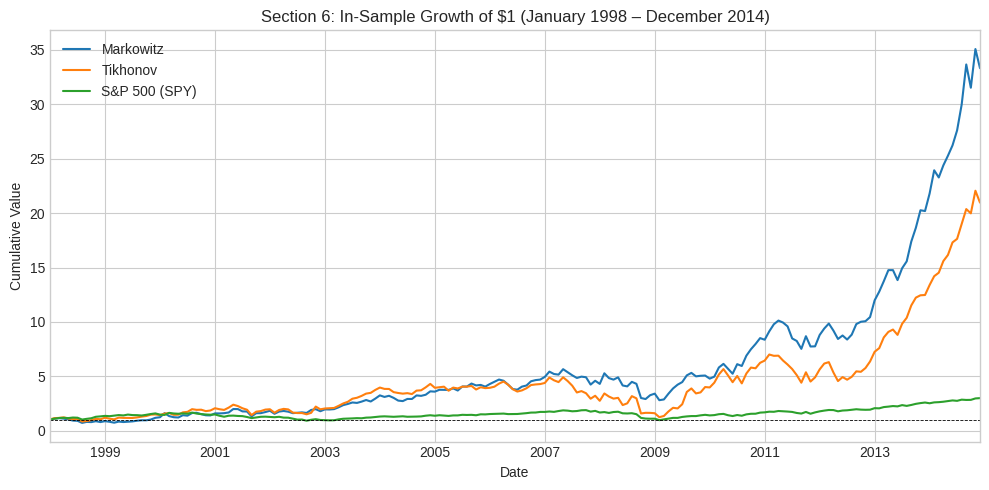

In [47]:
#In-sample cumulative paths
wealth_train = pd.DataFrame({
    'Markowitz':     (1 + port_mkv_train).cumprod(),
    'Tikhonov':      (1 + port_tikh_train).cumprod(),
    'S&P 500 (SPY)': (1 + spy_train).cumprod(),
}, index=train.index)

ax = wealth_train.plot(figsize=(10, 5))
ax.set_title('Section 6: In-Sample Growth of $1 (January 1998 – December 2014)', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Value')
ax.axhline(1.0, color='black', linewidth=0.6, linestyle='--')
plt.tight_layout()
plt.show()

## Out-of-Sample Performance Analysis

The **same weights** estimated from the in-sample window are applied unchanged to the **out-of-sample period (January 2015 – December 2024, 120 months)**. No weights are refit and no out-of-sample information is used.

### Portfolio Return Construction (Out-of-Sample)

In [48]:
#Portfolio return series (out-of-sample, in-sample weights)
port_mkv_test  = test[my_stock_selection] @ w_mkv_train
port_tikh_test = test[my_stock_selection] @ w_tikh_train
spy_test       = test['SPY']

print(f'Out-of-sample period: {test.index.min().date()} to {test.index.max().date()} ({len(test)} months)')
print(f'Markowitz mean monthly return : {port_mkv_test.mean():.6f}')
print(f'Tikhonov  mean monthly return : {port_tikh_test.mean():.6f}')
print(f'S&P 500   mean monthly return : {spy_test.mean():.6f}')

Out-of-sample period: 2015-01-01 to 2024-12-01 (120 months)
Markowitz mean monthly return : 0.021537
Tikhonov  mean monthly return : 0.022701
S&P 500   mean monthly return : 0.011330


### Mean Returns and S&P 500 Benchmark Regression (Out-of-Sample)

$$r_{p,t} = \alpha + \beta \cdot r_{\text{SPY},t} + \varepsilon_t$$

In [49]:
benchmark_outsample = pd.concat([
    sp500_benchmark_regression(port_mkv_test,  spy_test, 'Markowitz'),
    sp500_benchmark_regression(port_tikh_test, spy_test, 'Tikhonov'),
], axis=1).T
print('Out-of-Sample S&P 500 Benchmark Regression')
benchmark_outsample


Out-of-Sample S&P 500 Benchmark Regression


,Mean portfolio return (monthly),Mean S&P 500 return (monthly),Alpha (monthly),Alpha (annualised),Alpha t-stat,Beta (S&P 500),R-squared
Markowitz,0.021537,0.011330,0.007925,0.099354,1.474960,1.201386,0.490043
Tikhonov,0.022701,0.011330,0.009124,0.115154,2.129098,1.198336,0.600455


### Fama-French Factor Regressions (Out-of-Sample)

In [50]:
mkv_models_test  = display_ff_results(port_mkv_test,  test, 'Markowitz', 'Out-of-Sample')
tikh_models_test = display_ff_results(port_tikh_test, test, 'Tikhonov',  'Out-of-Sample')


=== Markowitz — Out-of-Sample ===

  CAPM  (R²=0.4410)
           Coef   t-stat
const  0.008800 1.585600
Mkt-RF 1.150500 9.649300

  FF3  (R²=0.4482)
            Coef    t-stat
const   0.009700  1.714500
Mkt-RF  1.100300  8.708700
SMB     0.250800  1.217100
HML    -0.050700 -0.326600

  FF5  (R²=0.4510)
            Coef    t-stat
const   0.010300  1.798300
Mkt-RF  1.103700  8.259700
SMB     0.160300  0.670300
HML     0.037900  0.173500
RMW    -0.202000 -0.666000
CMA    -0.123200 -0.375200

=== Tikhonov — Out-of-Sample ===

  CAPM  (R²=0.5698)
           Coef    t-stat
const  0.009700  2.209300
Mkt-RF 1.178000 12.501000

  FF3  (R²=0.6061)
           Coef    t-stat
const  0.011200  2.612200
Mkt-RF 1.118200 11.629100
SMB    0.258400  1.647800
HML    0.242400  2.053000

  FF5  (R²=0.6105)
            Coef    t-stat
const   0.011500  2.651700
Mkt-RF  1.094400 10.794000
SMB     0.206100  1.135400
HML     0.372500  2.243800
RMW    -0.050500 -0.219400
CMA    -0.274200 -1.100800


In [51]:
ff5_outsample_summary = pd.concat([
    compact_ff5(mkv_models_test['FF5'],  'Markowitz'),
    compact_ff5(tikh_models_test['FF5'], 'Tikhonov'),
])
print('=== Section 7b-ii: FF5 Out-of-Sample Factor Loadings Summary ===')
ff5_outsample_summary.round(4)

=== Section 7b-ii: FF5 Out-of-Sample Factor Loadings Summary ===


Coefficient    t-stat
Markowitz Alpha      0.010300  1.798300
          Mkt-RF     1.103700  8.259700
          SMB        0.160300  0.670300
          HML        0.037900  0.173500
          RMW       -0.202000 -0.666000
          CMA       -0.123200 -0.375200
Tikhonov  Alpha      0.011500  2.651700
          Mkt-RF     1.094400 10.794000
          SMB        0.206100  1.135400
          HML        0.372500  2.243800
          RMW       -0.050500 -0.219400
          CMA       -0.274200 -1.100800

### Out-of-Sample Performance Comparison: Markowitz vs Tikhonov

In [52]:
out_sample_comparison = pd.concat([
    perf_summary(port_mkv_test,  test, spy_test, 'Markowitz'),
    perf_summary(port_tikh_test, test, spy_test, 'Tikhonov'),
    perf_summary(spy_test,       test, spy_test, 'S&P 500'),
], axis=1).T
print('=== Section 7b-iv: Out-of-Sample Performance Comparison ===')
out_sample_comparison.round(4)

=== Section 7b-iv: Out-of-Sample Performance Comparison ===


,Mean return (monthly),Std dev (monthly),Sharpe (annualised),CAPM Alpha (monthly),CAPM Alpha (annualised),CAPM Alpha t-stat,Market Beta (Mkt-RF),Max drawdown
Markowitz,0.021500,0.079700,0.877600,0.008800,0.111400,1.585600,1.150500,-0.330400
Tikhonov,0.022700,0.071800,1.030500,0.009700,0.123200,2.209300,1.178000,-0.330100
S&P 500,0.011300,0.046400,0.741500,0.000400,0.005100,0.337600,0.967800,-0.229200


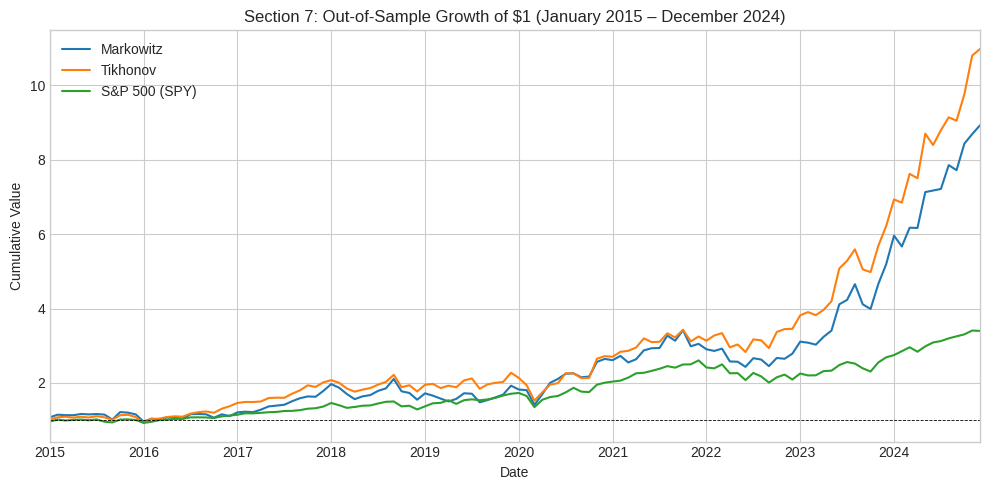

In [53]:
# Out-of-sample cumulative paths
wealth_test = pd.DataFrame({
    'Markowitz':     (1 + port_mkv_test).cumprod(),
    'Tikhonov':      (1 + port_tikh_test).cumprod(),
    'S&P 500 (SPY)': (1 + spy_test).cumprod(),
}, index=test.index)

ax = wealth_test.plot(figsize=(10, 5))
ax.set_title('Section 7: Out-of-Sample Growth of $1 (January 2015 – December 2024)', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Value')
ax.axhline(1.0, color='black', linewidth=0.6, linestyle='--')
plt.tight_layout()
plt.show()

## In-Sample vs Out-of-Sample Performance

Side-by-side comparison of both portfolios across the two periods, benchmarked against SPY.

In [54]:
full_comparison = pd.concat([
    in_sample_comparison.assign(Period='In-sample (1998–2014)'),
    out_sample_comparison.assign(Period='Out-of-sample (2015–2024)'),
]).reset_index().rename(columns={'index': 'Portfolio'}).set_index(['Period', 'Portfolio'])
print('=== Section 8: Full Performance Comparison ===')
full_comparison.round(4)

=== Section 8: Full Performance Comparison ===


Mean return (monthly)  Std dev (monthly)  \
Period                    Portfolio                                             
In-sample (1998–2014)     Markowitz               0.021100           0.086500   
                          Tikhonov                0.020600           0.105100   
                          S&P 500                 0.006500           0.046600   
Out-of-sample (2015–2024) Markowitz               0.021500           0.079700   
                          Tikhonov                0.022700           0.071800   
                          S&P 500                 0.011300           0.046400   

                                     Sharpe (annualised)  \
Period                    Portfolio                        
In-sample (1998–2014)     Markowitz             0.770100   
                          Tikhonov              0.619400   
                          S&P 500               0.349000   
Out-of-sample (2015–2024) Markowitz             0.877600   
                          Tikhonov              1.030500   
                          S&P 500               0.741500   

                                     CAPM Alpha (monthly)  \
Period                    Portfolio                         
In-sample (1998–2014)     Markowitz              0.013900   
                          Tikhonov               0.011300   
                          S&P 500                0.000300   
Out-of-sample (2015–2024) Markowitz              0.008800   
                          Tikhonov               0.009700   
                          S&P 500                0.000400   

                                     CAPM Alpha (annualised)  \
Period                    Portfolio                            
In-sample (1998–2014)     Markowitz                 0.180600   
                          Tikhonov                  0.143800   
                          S&P 500                   0.003300   
Out-of-sample (2015–2024) Markowitz                 0.111400   
                          Tikhonov                  0.123200   
                          S&P 500                   0.005100   

                                     CAPM Alpha t-stat  Market Beta (Mkt-RF)  \
Period                    Portfolio                                            
In-sample (1998–2014)     Markowitz           2.823600              1.098500   
                          Tikhonov            2.092100              1.555400   
                          S&P 500             0.200200              0.909800   
Out-of-sample (2015–2024) Markowitz           1.585600              1.150500   
                          Tikhonov            2.209300              1.178000   
                          S&P 500             0.337600              0.967800   

                                     Max drawdown  
Period                    Portfolio                
In-sample (1998–2014)     Markowitz     -0.503400  
                          Tikhonov      -0.745700  
                          S&P 500       -0.484800  
Out-of-sample (2015–2024) Markowitz     -0.330400  
                          Tikhonov      -0.330100  
                          S&P 500       -0.229200

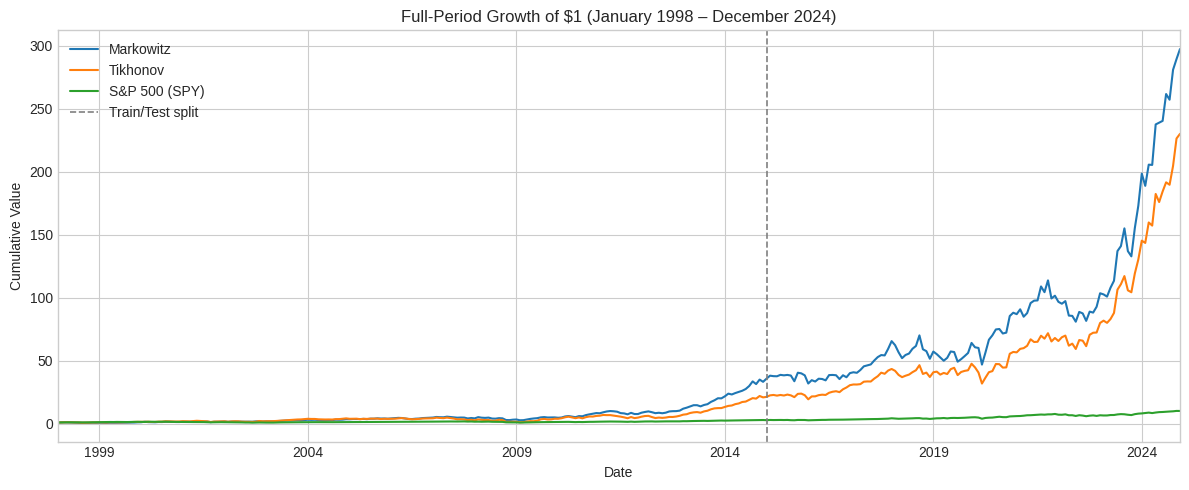

In [55]:
#Combined wealth path: both periods
wealth_full = pd.DataFrame({
    'Markowitz':     pd.concat([(1 + port_mkv_train).cumprod(),
                                (1 + port_mkv_test).cumprod() * (1 + port_mkv_train).cumprod().iloc[-1]]),
    'Tikhonov':      pd.concat([(1 + port_tikh_train).cumprod(),
                                (1 + port_tikh_test).cumprod() * (1 + port_tikh_train).cumprod().iloc[-1]]),
    'S&P 500 (SPY)': pd.concat([(1 + spy_train).cumprod(),
                                (1 + spy_test).cumprod() * (1 + spy_train).cumprod().iloc[-1]]),
})

ax = wealth_full.plot(figsize=(12, 5))
ax.axvline(pd.Timestamp('2015-01-01'), color='grey', linestyle='--', linewidth=1.2, label='Train/Test split')
ax.set_title('Full-Period Growth of $1 (January 1998 – December 2024)', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Value')
ax.legend()
plt.tight_layout()
plt.show()

## Portfolio Method Selection

In [56]:
# Summary of key metrics for method selection decision
method_selection = pd.DataFrame({
    'In-sample Sharpe':      [in_sample_comparison.loc['Markowitz','Sharpe (annualised)'],
                              in_sample_comparison.loc['Tikhonov', 'Sharpe (annualised)']],
    'OOS Sharpe':            [out_sample_comparison.loc['Markowitz','Sharpe (annualised)'],
                              out_sample_comparison.loc['Tikhonov', 'Sharpe (annualised)']],
    'In-sample Alpha t-stat':[in_sample_comparison.loc['Markowitz','CAPM Alpha t-stat'],
                              in_sample_comparison.loc['Tikhonov', 'CAPM Alpha t-stat']],
    'OOS Alpha t-stat':      [out_sample_comparison.loc['Markowitz','CAPM Alpha t-stat'],
                              out_sample_comparison.loc['Tikhonov', 'CAPM Alpha t-stat']],
    'Max Drawdown (OOS)':    [out_sample_comparison.loc['Markowitz','Max drawdown'],
                              out_sample_comparison.loc['Tikhonov', 'Max drawdown']],
}, index=['Markowitz', 'Tikhonov'])
method_selection.round(4)

,In-sample Sharpe,OOS Sharpe,In-sample Alpha t-stat,OOS Alpha t-stat,Max Drawdown (OOS)
Markowitz,0.770100,0.877600,2.823600,1.585600,-0.330400
Tikhonov,0.619400,1.030500,2.092100,2.209300,-0.330100
